In [ ]:
# Core imports for the whole lab
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
print('Setup complete. pandas', pd.__version__)

Setup complete. pandas 2.2.2


In [ ]:

# -----------------------------------------------------------
# A SMALL, ALREADY-CLEAN DATASET (Part 1 did the cleaning)
# -----------------------------------------------------------
# Mixed columns: an unordered category (city), an ordered category
# (size), two numeric features on very different scales, and a target.
df = pd.DataFrame({
    'city':   ['pune', 'delhi', 'mumbai', 'pune', 'delhi', 'mumbai', 'pune', 'delhi'],
    'size':   ['small', 'large', 'medium', 'medium', 'small', 'large', 'large', 'small'],
    'age':    [25, 41, 33, 29, 52, 38, 46, 22],
    'income': [38000, 92000, 55000, 47000, 120000, 76000, 88000, 41000],
    'bought': [0, 1, 0, 0, 1, 1, 1, 0],   # target
})
df

,city,size,age,income,bought
0,pune,small,25,38000,0
1,delhi,large,41,92000,1
2,mumbai,medium,33,55000,0
3,pune,medium,29,47000,0
4,delhi,small,52,120000,1
5,mumbai,large,38,76000,1
6,pune,large,46,88000,1
7,delhi,small,22,41000,0


In [ ]:

# -----------------------------------------------------------
# 🔹 1A. ONE-HOT ENCODING (for UNORDERED categories)
# -----------------------------------------------------------

# 'city' has no natural order -> one 0/1 column per category
city_ohe = pd.get_dummies(df['city'], prefix='city').astype(int)
city_ohe

,city_delhi,city_mumbai,city_pune
0,0,0,1
1,1,0,0
2,0,1,0
3,0,0,1
4,1,0,0
5,0,1,0
6,0,0,1
7,1,0,0


In [ ]:
# -----------------------------------------------------------
# 🔹 1B. LABEL / ORDINAL ENCODING (for ORDERED categories)
# -----------------------------------------------------------

# 'size' has a real order: small < medium < large -> map to 0,1,2
size_order = {'small': 0, 'medium': 1, 'large': 2}
df['size_code'] = df['size'].map(size_order)
df[['size', 'size_code']]

,size,size_code
0,small,0
1,large,2
2,medium,1
3,medium,1
4,small,0
5,large,2
6,large,2
7,small,0


In [ ]:
# 1. one-hot encode just the 'city' column of the whole df
df_ohe = pd.get_dummies(df, columns=['city'])

# 2. ordinal-encode 'size' (map with size_order)
df_ohe['size_code'] = df_ohe['size'].map(size_order)
df_ohe = df_ohe.drop(columns=['size'])
df_ohe

# 3. Why one-hot is wrong for size / ordinal is wrong for city:
#    - One-hot encoding for 'size' would imply no order between 'small', 'medium', 'large',
#      which is incorrect as 'size' has a natural order. It would also create unnecessary columns.
#    - Ordinal encoding for 'city' would imply an arbitrary order (e.g., pune < delhi < mumbai),
#      which does not exist for an unordered categorical feature like 'city'. This would introduce
#      a false sense of numerical relationship that can mislead models.

,age,income,bought,size_code,city_delhi,city_mumbai,city_pune
0,25,38000,0,0,False,False,True
1,41,92000,1,2,True,False,False
2,33,55000,0,1,False,True,False
3,29,47000,0,1,False,False,True
4,52,120000,1,0,True,False,False
5,38,76000,1,2,False,True,False
6,46,88000,1,2,False,False,True
7,22,41000,0,0,True,False,False


In [ ]:

# -----------------------------------------------------------
# 🔹 2A. THE PROBLEM — FEATURES ON DIFFERENT SCALES
# -----------------------------------------------------------

# income (tens of thousands) dwarfs age (tens). A distance-based
# model would treat income as nearly all that matters.
print(df[['age', 'income']].describe().loc[['min', 'max', 'mean']])

        age    income
min   22.00   38000.0
max   52.00  120000.0
mean  35.75   69625.0


In [ ]:
# -----------------------------------------------------------
# 🔹 2B. STANDARDISATION (Z-score)  vs  NORMALISATION (Min-Max)
# -----------------------------------------------------------
from sklearn.preprocessing import StandardScaler, MinMaxScaler

num = df[['age', 'income']]

z = StandardScaler().fit_transform(num)        # mean 0, std 1
m = MinMaxScaler().fit_transform(num)          # range [0, 1]

print('Standardised (mean~0, std~1):')
print(pd.DataFrame(z, columns=['age', 'income']).round(2).head(3))
print('\nMin-Max (range 0..1):')
print(pd.DataFrame(m, columns=['age', 'income']).round(2).head(3))

Standardised (mean~0, std~1):
    age  income
0 -1.10   -1.16
1  0.54    0.82
2 -0.28   -0.54

Min-Max (range 0..1):
    age  income
0  0.10    0.00
1  0.63    0.66
2  0.37    0.21


In [ ]:
income = df[['income']]   # 2D shape for sklearn

# 1. standardise -> check mean ~0, std ~1

z = StandardScaler().fit_transform(income)
print(pd.DataFrame(z, columns=['income']).round(2).head(3))
# 2. min-max scale -> check min 0, max 1
m = MinMaxScaler().fit_transform(income)
print(pd.DataFrame(m, columns=['income']).round(2).head(3))

# 3. Needs scaling: ...   Doesn't need it: ...   (comment)
#income needs scaling

   income
0   -1.16
1    0.82
2   -0.54
   income
0    0.00
1    0.66
2    0.21


In [ ]:

# -----------------------------------------------------------
# 🔹 3A. SPLIT FIRST, THEN FIT ON TRAIN ONLY
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[['age', 'income']]
y = df['bought']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # FIT + transform on train
X_test_s  = scaler.transform(X_test)        # only TRANSFORM on test
print('train rows:', X_train.shape[0], '| test rows:', X_test.shape[0])
print('scaler learned mean from TRAIN only:', scaler.mean_.round(1))


train rows: 6 | test rows: 2
scaler learned mean from TRAIN only: [3.45e+01 6.90e+04]


In [ ]:
# 1a. WRONG: fit on ALL data, then split (leakage!)
wrong_mean = StandardScaler().fit(X).mean_

# 1b. RIGHT: fit on TRAIN only
right_mean = StandardScaler().fit(X_train).mean_

print('fit-on-all mean :', wrong_mean.round(1))
print('fit-on-train mean:', right_mean.round(1))

# 2. Why fitting on all data is a problem: ...   (write your answer)
#This can lead to an artificially inflated performance estimate because your model implicitly 'saw' some information about the test data during its preparation, making it less representative of real-world, unseen data performance.

fit-on-all mean : [3.5800e+01 6.9625e+04]
fit-on-train mean: [3.45e+01 6.90e+04]


In [ ]:
# -----------------------------------------------------------
# 🔹 4A. COMBINE & BIN EXISTING COLUMNS
# -----------------------------------------------------------

fe = df.copy()
# combine: income per year of age (a crude 'earning rate')
fe['income_per_age'] = (fe['income'] / fe['age']).round(0)
# bin: turn continuous age into life-stage buckets
fe['age_group'] = pd.cut(fe['age'], bins=[0, 30, 45, 100],
                         labels=['young', 'mid', 'senior'])
fe[['age', 'income', 'income_per_age', 'age_group']]

,age,income,income_per_age,age_group
0,25,38000,1520.0,young
1,41,92000,2244.0,mid
2,33,55000,1667.0,mid
3,29,47000,1621.0,young
4,52,120000,2308.0,senior
5,38,76000,2000.0,mid
6,46,88000,1913.0,senior
7,22,41000,1864.0,young


In [ ]:

# -----------------------------------------------------------
# 🔹 4B. EXTRACT FROM A DATE
# -----------------------------------------------------------

dates = pd.to_datetime(['2024-01-06', '2024-03-15', '2024-07-21', '2024-12-25'])
d = pd.DataFrame({'date': dates})
d['day_of_week'] = d['date'].dt.day_name()   # Monday, Tuesday, ...
d['month']       = d['date'].dt.month
d['is_weekend']  = d['date'].dt.dayofweek >= 5
d

,date,day_of_week,month,is_weekend
0,2024-01-06,Saturday,1,True
1,2024-03-15,Friday,3,False
2,2024-07-21,Sunday,7,True
3,2024-12-25,Wednesday,12,False


In [ ]:

ex = df.copy()

# 1. high_earner flag (income > median)
ex['high_earner'] = (ex['income'] > ex['income'].median()).astype(int)


# 2. bin income into 3 buckets with pd.cut
ex['income_group'] = pd.cut(ex['income'], bins=3, labels=['low', 'medium', 'high'])

# 3. show income + the new columns
ex[['income', 'high_earner', 'income_group']]


,income,high_earner,income_group
0,38000,0,low
1,92000,1,medium
2,55000,0,low
3,47000,0,low
4,120000,1,high
5,76000,1,medium
6,88000,1,medium
7,41000,0,low


In [ ]:
# -----------------------------------------------------------
# 🔹 5A. ONE LEAK-FREE PIPELINE: PREPROCESS + MODEL
# -----------------------------------------------------------
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

num_cols = ['age', 'income']
cat_cols = ['city', 'size']

# scale the numbers, one-hot the categories — all in one object
pre = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])
pipe = Pipeline([('prep', pre), ('model', LogisticRegression(max_iter=1000))])
print(pipe)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'income']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['city', 'size'])])),
                ('model', LogisticRegression(max_iter=1000))])


In [ ]:

# -----------------------------------------------------------
# 🔹 5B. FIT THE WHOLE THING IN ONE CALL
# -----------------------------------------------------------

X = df[num_cols + cat_cols]
y = df['bought']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0)

pipe.fit(X_train, y_train)        # preprocessing fitted on TRAIN only — no leakage
acc = pipe.score(X_test, y_test)  # transforms test with train-fitted steps
print('Test accuracy:', round(acc, 2))
print('(small toy dataset — the point is the leak-free workflow, not the score)')

Test accuracy: 1.0
(small toy dataset — the point is the leak-free workflow, not the score)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

Xn = df[['age', 'income']]
yn = df['bought']

# 1. Pipeline: MinMaxScaler -> LogisticRegression
pre = Pipeline([
    ('scale', MinMaxScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

# 2. split + fit on train
X_train, X_test, y_train, y_test = train_test_split(
    Xn, yn, test_size=0.25, random_state=0)
pre.fit(X_train, y_train)

# 3. print test accuracy
acc = pre.score(X_test, y_test)
print('Test accuracy:', round(acc, 2))



Test accuracy: 1.0


##**EDA EXERCISE#



In [ ]:
# === SETUP: load the provided data files (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd

def build_datasets(csv_path='ecommerce_customers.csv',
                   xlsx_path='transactions.xlsx', seed=42, verbose=False):
    """Generate a realistic e-commerce customer + transactions dataset.

    Baked-in realism for EDA / feature engineering practice:
      - right-skewed monetary columns (total_spend) with a few 'whale' outliers
      - class imbalance in is_churned (~20-30%)
      - real signal: churn depends on recency, order count and support tickets
      - missing values in age / gender / city
      - a high-cardinality 'city' column (long tail of rare cities)
      - customers with zero orders (no last_order_date) -> dormant
    The Excel file is order-level and is CONSISTENT with the customer table
    (num_orders / total_spend / last_order_date are derived from it).
    """
    rng = np.random.default_rng(seed)
    N = 2500
    start = pd.Timestamp('2021-01-01')
    end = pd.Timestamp('2024-06-30')
    horizon = (end - start).days

    cust = np.array([f'CUST{i+1:05d}' for i in range(N)])
    signup_off = rng.integers(0, horizon - 60, N)
    signup = start + pd.to_timedelta(signup_off, unit='D')

    # order counts: overdispersed (gamma-poisson), some customers have zero
    lam = rng.gamma(2.0, 1.6, N)
    num_orders = rng.poisson(lam)

    # ---- order-level transactions (vectorised) ----
    counts = num_orders
    tot = int(counts.sum())
    cust_rep = np.repeat(cust, counts)
    signup_rep = np.repeat(signup_off, counts)
    span = np.maximum(horizon - signup_off, 1)
    span_rep = np.repeat(span, counts)
    off = (rng.random(tot) * span_rep).astype(int)
    tx_off = signup_rep + off
    tx_date = start + pd.to_timedelta(tx_off, unit='D')
    amount = rng.lognormal(3.2, 0.8, tot).round(2)        # right-skewed (~tens of currency)
    category = rng.choice(['Electronics', 'Fashion', 'Grocery', 'Home', 'Books'],
                          tot, p=[.20, .30, .25, .15, .10])
    tx = pd.DataFrame({'customer_id': cust_rep, 'order_date': tx_date,
                       'amount': amount, 'category': category}).sort_values(
        ['customer_id', 'order_date']).reset_index(drop=True)

    # ---- aggregate transactions -> customer level ----
    agg = tx.groupby('customer_id').agg(
        total_spend=('amount', 'sum'),
        first_order=('order_date', 'min'),
        last_order=('order_date', 'max'),
    ).reset_index()

    df = pd.DataFrame({'customer_id': cust, 'signup_date': signup,
                       'num_orders': num_orders})
    df = df.merge(agg, on='customer_id', how='left')
    df['total_spend'] = df['total_spend'].fillna(0).round(2)

    # ---- demographics & account attributes ----
    df['age'] = np.clip(rng.normal(38, 12, N), 18, 82).round().astype(int)
    df['gender'] = rng.choice(['M', 'F', 'Other'], N, p=[.48, .48, .04])

    majors = ['Mumbai', 'Delhi', 'Bengaluru', 'Hyderabad', 'Chennai', 'Pune', 'Kolkata']
    rare = ['Jaipur', 'Surat', 'Indore', 'Bhopal', 'Patna', 'Nagpur',
            'Kochi', 'Coimbatore', 'Visakhapatnam', 'Lucknow']
    pool = majors + rare
    w = np.array([.17, .15, .14, .12, .10, .08, .06] + [.013] * 10)
    w = w / w.sum()
    df['city'] = rng.choice(pool, N, p=w)

    df['plan'] = rng.choice(['Basic', 'Standard', 'Premium'], N, p=[.50, .35, .15])
    df['device'] = rng.choice(['Mobile', 'Desktop', 'Tablet'], N, p=[.60, .32, .08])
    df['payment_method'] = rng.choice(['Card', 'UPI', 'Wallet', 'NetBanking'],
                                      N, p=[.40, .35, .15, .10])
    df['support_tickets'] = rng.poisson(0.6, N)
    df['email_opt_in'] = rng.choice([0, 1], N, p=[.35, .65])

    # ---- churn target with real signal (recency / orders / tickets) ----
    last = pd.to_datetime(df['last_order'])
    days_since = (end - last).dt.days
    days_since_filled = days_since.fillna(horizon).to_numpy()
    z = (-2.75
         + 0.0019 * days_since_filled
         + 0.30 * df['support_tickets'].to_numpy()
         - 0.05 * df['num_orders'].to_numpy()
         + 0.70 * (df['num_orders'].to_numpy() == 0))
    p = 1 / (1 + np.exp(-z))
    df['is_churned'] = (rng.random(N) < p).astype(int)

    # ---- format dates as ISO strings (NaT -> ) ----
    df = df.rename(columns={'first_order': 'first_order_date',
                            'last_order': 'last_order_date'})
    for c in ['signup_date', 'first_order_date', 'last_order_date']:
        df[c] = pd.to_datetime(df[c]).dt.date.astype('string')

    df = df[['customer_id', 'signup_date', 'first_order_date', 'last_order_date',
             'age', 'gender', 'city', 'plan', 'device', 'payment_method',
             'num_orders', 'total_spend', 'support_tickets', 'email_opt_in',
             'is_churned']]

    # ---- inject missing values AFTER computing the target ----
    def punch(col, frac):
        idx = rng.choice(N, int(frac * N), replace=False)
        df.loc[idx, col] = np.nan
    punch('age', 0.07)
    punch('gender', 0.04)
    punch('city', 0.02)

    # ---- write files ----
    df.to_csv(csv_path, index=False)
    tx_out = tx.copy()
    tx_out['order_date'] = pd.to_datetime(tx_out['order_date']).dt.date.astype('string')
    tx_out.to_excel(xlsx_path, index=False)

    if verbose:
        print('customers:', df.shape, '| transactions:', tx_out.shape)
        print('churn rate:', round(df["is_churned"].mean(), 3))
        print('total_spend skew:', round(df["total_spend"].skew(), 2))
        print('missing age:', int(df["age"].isna().sum()),
              '| missing city:', int(df["city"].isna().sum()))
        print('zero-order customers:', int((df["num_orders"] == 0).sum()))
        print('distinct cities:', df["city"].nunique())
    return df, tx_out

if not (os.path.exists('ecommerce_customers.csv') and os.path.exists('transactions.xlsx')):
    build_datasets()   # creates the two resource files locally
    print('Generated dataset files.')
else:
    print('Found the provided dataset files.')

Found the provided dataset files.


In [ ]:
# Load the customer table (parse the date columns as real datetimes)
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

df = pd.read_csv('ecommerce_customers.csv',
                 parse_dates=['signup_date', 'first_order_date', 'last_order_date'])
print('Loaded', df.shape[0], 'customers x', df.shape[1], 'columns')
df.head()

Loaded 2500 customers x 15 columns


,customer_id,signup_date,first_order_date,last_order_date,age,gender,city,plan,device,payment_method,num_orders,total_spend,support_tickets,email_opt_in,is_churned
0,CUST00001,2021-04-19,NaT,NaT,31.0,F,Chennai,Premium,Desktop,Card,0,0.00,2,0,0
1,CUST00002,2023-07-31,NaT,NaT,54.0,F,Hyderabad,Standard,Desktop,Wallet,0,0.00,1,0,1
2,CUST00003,2023-03-07,2023-05-22,2023-05-22,43.0,Other,Pune,Premium,Mobile,Wallet,1,39.17,1,0,0
3,CUST00004,2022-06-18,2022-07-02,2022-07-02,28.0,F,Pune,Standard,Desktop,Card,1,2.74,1,1,0
4,CUST00005,2022-06-11,2022-09-18,2024-06-15,30.0,F,Mumbai,Standard,Mobile,Wallet,4,133.80,0,0,0


In [ ]:
df.info()
print('Missing values (%):')
print((df.isna().mean() * 100).round(1).sort_values(ascending=False).head(6))
print('\nChurn rate (target):', round(df['is_churned'].mean(), 3))
print('Customers with zero orders:', int((df['num_orders'] == 0).sum()))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       2500 non-null   object        
 1   signup_date       2500 non-null   datetime64[ns]
 2   first_order_date  2131 non-null   datetime64[ns]
 3   last_order_date   2131 non-null   datetime64[ns]
 4   age               2325 non-null   float64       
 5   gender            2400 non-null   object        
 6   city              2450 non-null   object        
 7   plan              2500 non-null   object        
 8   device            2500 non-null   object        
 9   payment_method    2500 non-null   object        
 10  num_orders        2500 non-null   int64         
 11  total_spend       2500 non-null   float64       
 12  support_tickets   2500 non-null   int64         
 13  email_opt_in      2500 non-null   int64         
 14  is_churned        2500 n

In [ ]:

# 1. is customer_id unique?
print('customer_id is unique:', df['customer_id'].is_unique)

# 2. numeric summary

# YOUR CODE HERE
print(df.describe())

# 3. Three issues I can see: ...   (comment)


customer_id is unique: True
                      signup_date               first_order_date  \
count                        2500                           2131   
mean   2022-08-29 07:45:59.040000  2023-03-07 03:13:56.227123200   
min           2021-01-01 00:00:00            2021-01-24 00:00:00   
25%           2021-10-30 00:00:00            2022-07-06 12:00:00   
50%           2022-08-24 12:00:00            2023-04-22 00:00:00   
75%           2023-07-01 00:00:00            2023-12-05 00:00:00   
max           2024-04-30 00:00:00            2024-06-28 00:00:00   
std                           NaN                            NaN   

                     last_order_date          age   num_orders  total_spend  \
count                           2131  2325.000000  2500.000000  2500.000000   
mean   2024-01-01 16:56:59.239793664    37.888602     3.260800   112.272900   
min              2021-03-23 00:00:00    18.000000     0.000000     0.000000   
25%              2023-10-20 00:00:00    30.

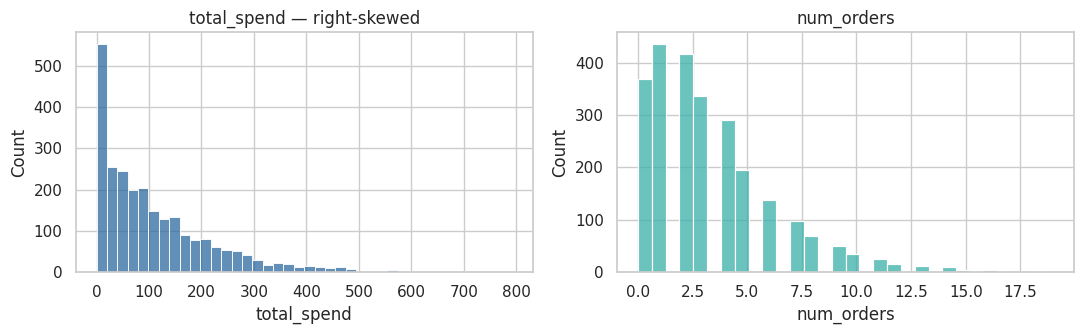

In [ ]:

# -----------------------------------------------------------
# 🔹 2A. DISTRIBUTION OF SPEND  (note the long right tail)
# -----------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(df['total_spend'], bins=40, ax=ax[0], color='#2D6A9F')
ax[0].set_title('total_spend — right-skewed')
sns.histplot(df['num_orders'], bins=30, ax=ax[1], color='#3AAFA9')
ax[1].set_title('num_orders')
plt.tight_layout(); plt.show()

<Axes: xlabel='age', ylabel='Count'>

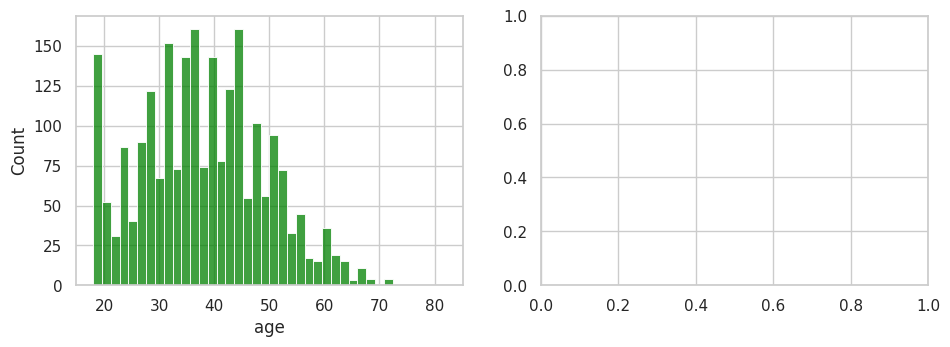

In [ ]:
# 1. histogram of age (drop NaN)
# YOUR CODE HERE
df_age = df.dropna(subset=['age'])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(df_age['age'], bins=40, ax=ax[0], color='green')

# 2. Shape description: ...   (comment)

In [ ]:
# -----------------------------------------------------------
# 🔹 3A. MEAN vs MEDIAN ON A SKEWED COLUMN
# -----------------------------------------------------------
# When data is right-skewed, the mean is pulled up by big spenders.
spend = df['total_spend']
print('mean  :', round(spend.mean(), 1))
print('median:', round(spend.median(), 1))
print('skew  :', round(spend.skew(), 2), ' (> 0 means right-skewed)')
print('\nThe mean > median gap is the skew talking.')

mean  : 112.3
median: 79.1
skew  : 1.73  (> 0 means right-skewed)

The mean > median gap is the skew talking.


In [ ]:
# 1. skew of the two columns
skew_values = df[['num_orders', 'total_spend']].skew()

print(skew_values)
# num_orders:
# Median preferred if skewed, because a few customers may place many orders.

# total_spend:
# Median preferred because the distribution is highly right-skewed and
# contains high-spending outliers. Median is more robust than mean.


num_orders     1.353011
total_spend    1.731732
dtype: float64


Plan mix:
plan
Basic       0.494
Standard    0.352
Premium     0.154
Name: proportion, dtype: float64

Top cities:
city
Mumbai       416
Delhi        405
Bengaluru    390
Hyderabad    320
Chennai      253
Name: count, dtype: int64


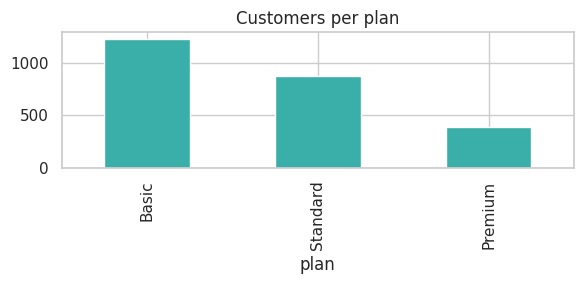

In [ ]:

# -----------------------------------------------------------
# 🔹 4A. CATEGORY FREQUENCIES
# -----------------------------------------------------------
print('Plan mix:')
print(df['plan'].value_counts(normalize=True).round(3))
print('\nTop cities:')
print(df['city'].value_counts().head(5))

fig, ax = plt.subplots(figsize=(6, 3))
df['plan'].value_counts().plot(kind='bar', ax=ax, color='#3AAFA9')
ax.set_title('Customers per plan'); plt.tight_layout(); plt.show()

In [ ]:
# 1. churn vs retained proportions
# YOUR CODE HERE
churn_proportions = df['is_churned'].value_counts(normalize=True)
print(churn_proportions)

# 2. imbalance ratio (retained / churned)
# YOUR CODE HERE
imbalance_ratio = churn_proportions[0] / churn_proportions[1]
print(imbalance_ratio)

# 3. bar chart of device + comment on the dominant category
# YOUR CODE HERE



is_churned
0    0.834
1    0.166
Name: proportion, dtype: float64
5.024096385542168


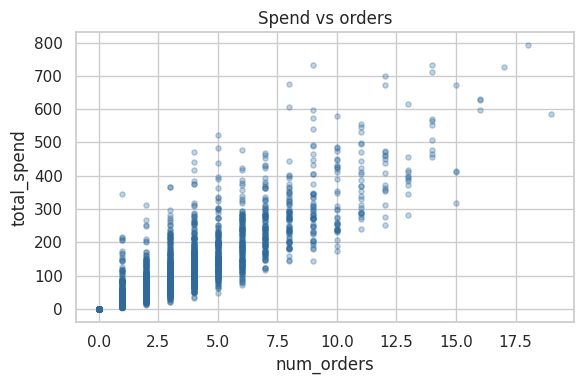

correlation: 0.864


In [ ]:

# -----------------------------------------------------------
# 🔹 5A. DO SPEND AND ORDER COUNT MOVE TOGETHER?
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df['num_orders'], df['total_spend'], alpha=0.3, color='#2D6A9F', s=14)
ax.set_xlabel('num_orders'); ax.set_ylabel('total_spend')
ax.set_title('Spend vs orders'); plt.tight_layout(); plt.show()

print('correlation:', round(df['num_orders'].corr(df['total_spend']), 3))

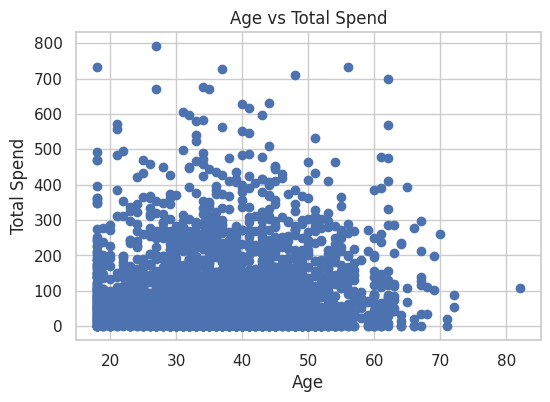

Correlation between Age and Total Spend: 0.006797896800715421


In [ ]:
# 1. scatter age vs total_spend

plt.figure(figsize=(6,4))
plt.scatter(df['age'], df['total_spend'])

plt.xlabel('Age')
plt.ylabel('Total Spend')
plt.title('Age vs Total Spend')

plt.show()


# 2. correlation
correlation_age_spend = df['age'].corr(df['total_spend'])
print('Correlation between Age and Total Spend:', correlation_age_spend)
# YOUR CODE HERE

# 3. Interpretation: ...   (comment)

            num_orders  total_spend  support_tickets
is_churned                                          
0                  3.6        125.5              0.6
1                  1.4         45.9              0.7


/tmp/ipykernel_1361/3518072038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_churned', y='num_orders', ax=ax,


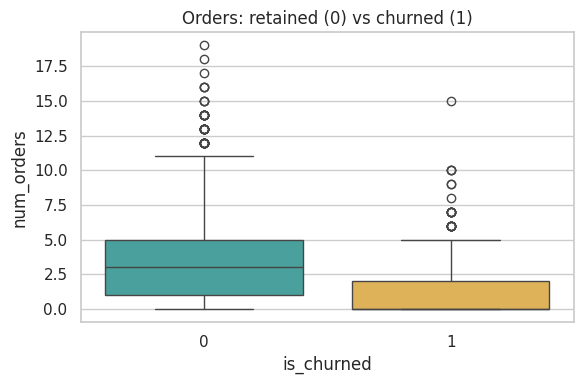

In [ ]:
# -----------------------------------------------------------
# 🔹 6A. HOW DO CHURNERS DIFFER?  (group means)
# -----------------------------------------------------------
cols = ['num_orders', 'total_spend', 'support_tickets']
print(df.groupby('is_churned')[cols].mean().round(1))

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x='is_churned', y='num_orders', ax=ax,
            palette=['#3AAFA9', '#F4B942'])
ax.set_title('Orders: retained (0) vs churned (1)')
plt.tight_layout(); plt.show()